# Subvolume-Weighted 2PCF Correction

When using `m < k` subvolumes drawn from `k` available realisations, pair counts are biased. The SCOPE/SUGC alpha-beta weighting scheme corrects for this by decomposing auto and cross pairs.

See `subvol_weighted_correction.py` for implementation details.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

import galform_analysis
from galform_analysis import set_base_dir, get_base_dir, SimulationConfig, load_redshift_mapping

mpl.setconfig()

# Configure the path to your GALFORM output directory once per session:
# set_base_dir('/cosma5/data/durham/<user>/Galform_Out/L800/model')
BASE_DIR = str(get_base_dir())
SIM = 'L800'

## Build the subvolume catalogue

In [2]:
from galform_analysis.analysis.correlation import (
    load_subvolume_galaxies,
    compute_weighted_xi_from_catalogue,
    compute_weighted_xi_for_n_list,
    compute_weighted_wp_from_catalogue,
)
from galform_analysis.config import SimulationConfig
import os

IZ_NUM = 155
IVOLS  = list(range(4))   # m subvolumes to use  (out of k total)
iz_path = os.path.join(BASE_DIR, f'iz{IZ_NUM}')

sim = SimulationConfig(SIM)
boxsize = sim.box_size

# Load galaxies tagged with their subvolume label
cat = load_subvolume_galaxies(BASE_DIR, IZ_NUM, ivols=IVOLS)
print(f"Catalogue: {len(cat):,} rows, labels={cat['partition_label'].unique().to_list()}")

Catalogue: 1,164,961 rows, labels=[0, 1, 2, 3]


## Weighted xi(r) at fixed m

In [3]:
from galform_analysis.config import DEFAULT_RBINS

xi_w = compute_weighted_xi_from_catalogue(
    cat,
    m_selected=len(IVOLS),
    k_total=sim.n_subvolumes,
    rbins=DEFAULT_RBINS,
    boxsize=boxsize,
)
print(xi_w)

{'r': array([ 0.11667607,  0.15559004,  0.20748266,  0.27668257,  0.36896213,
        0.49201891,  0.65611777,  0.8749471 ,  1.16676072,  1.55590042,
        2.07482656,  2.76682568,  3.68962135,  4.92018914,  6.56117767,
        8.74947105, 11.66760716, 15.55900421, 20.74826558, 27.66825683]), 'xi_standard': array([6.96865719e+04, 4.54304051e+04, 2.95478898e+04, 1.95113237e+04,
       1.23019789e+04, 7.58070925e+03, 4.63985840e+03, 2.72005084e+03,
       1.47703819e+03, 7.85833024e+02, 4.32474996e+02, 2.53549001e+02,
       1.50118865e+02, 9.00120268e+01, 5.07399717e+01, 2.35346583e+01,
       6.39206381e+00, 1.89408706e+00, 1.09451478e+00, 9.66519916e-01]), 'xi_corrected': array([272.62821136, 177.98863926, 116.38152185,  77.06727937,
        49.04832026,  30.78311638,  19.37473043,  11.83502733,
         6.98916501,   4.25109999,   2.98173282,   2.42449646,
         1.97863202,   1.7159049 ,   1.31469658,   1.17494742,
         1.10674395,   1.12527357,   1.07708384,   0.96284224]),

## Convergence over m (how many subvolumes are needed?)

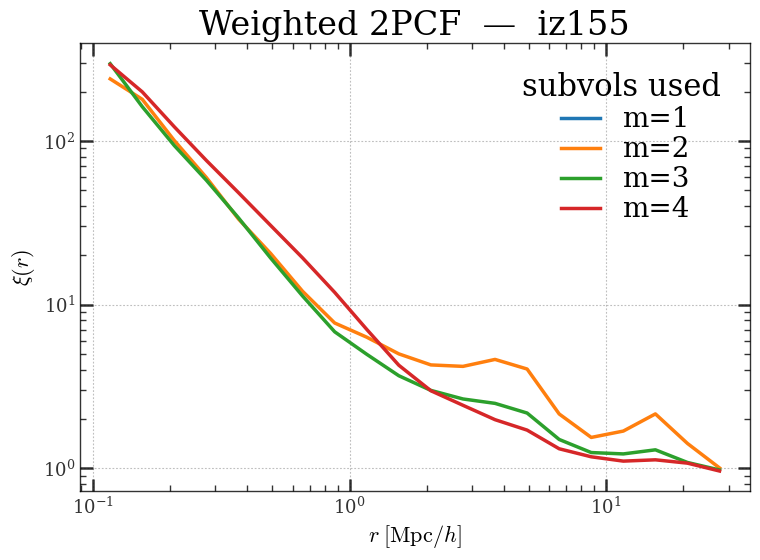

In [4]:
n_list = [1, 2, 3, 4]   # values of m to test

xi_list = compute_weighted_xi_for_n_list(
    BASE_DIR,
    IZ_NUM,
    n_subvol_list=n_list,
    rbins=DEFAULT_RBINS,
    boxsize=boxsize,
    k_total=sim.n_subvolumes,
)

fig, ax = plt.subplots()
for m in n_list:
    df_m = xi_list.filter(xi_list["n_subvol"] == m)
    ax.plot(df_m["r"], df_m["xi_corrected"], label=f"m={m}")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$r\;[\mathrm{Mpc}/h]$')
ax.set_ylabel(r'$\xi(r)$')
ax.set_title(f'Weighted 2PCF  —  iz{IZ_NUM}')
ax.legend(title='subvols used')
fig.tight_layout()
plt.show()